# RTB

## iPinYou Dataset

In [1]:
import pandas as pd

df_train = pd.read_csv('data/train_data.csv')
df_val = pd.read_csv('data/val_data.csv')
df_test = pd.read_csv('data/test_data.csv')

## DRL PPO

### iPinYou data

In [2]:
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import train_test_split
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from env_RTB import OfflineRTBEnv


train_env = Monitor(OfflineRTBEnv(df_train, target_revenue=300000, zeta=10))
val_env   = Monitor(OfflineRTBEnv(df_val,   target_revenue=300000, zeta=10))
test_env  = Monitor(OfflineRTBEnv(df_test,  target_revenue=300000, zeta=10))

# =========================
# 3. LOG DIR
# =========================
log_dir = "./logs_ppo_rtb/"
os.makedirs(log_dir, exist_ok=True)

# =========================
# 4. CALLBACK VALIDATION
# =========================
eval_callback = EvalCallback(
    val_env,
    best_model_save_path=log_dir + "best_model/",
    log_path=log_dir,
    eval_freq=5000,          # mỗi 5k step evaluate
    deterministic=True,
    render=False
)

# =========================
# 5. PPO CONFIG
# =========================
ppo_config = {
    "policy": "MlpPolicy",
    "env": train_env,
    "learning_rate": 2e-4,
    "n_steps": 1024,
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.2,
    "ent_coef": 0.08,
    "verbose": 1,
    "tensorboard_log": log_dir,  
    "device": "auto"
}

model = PPO(**ppo_config)

# =========================
# 6. TRAIN
# =========================
model.learn(
    total_timesteps=500000,   
    callback=eval_callback
)

# save model cuối
model.save(log_dir + "final_model_diffrewardbeta")

print("Training xong")

# =========================
# 7. EVALUATE FUNCTION
# =========================
def evaluate_agent(model, env, num_episodes=10):
    all_rewards = []
    all_revenues = []
    success = 0
    steps = 0

    for _ in range(num_episodes):
        obs, _ = env.reset()
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = env.step(action)

            all_rewards.append(reward)
            all_revenues.append(info.get('revenue', 0))

            if info.get('revenue', 0) > 0:
                success += 1
            steps += 1

    print("\n===== EVALUATION =====")
    print(f"Avg Reward: {np.mean(all_rewards):.4f}")
    print(f"Avg Revenue: {np.mean(all_revenues):.4f}")
    print(f"Deal Rate: {success/steps:.2%}")

    return np.mean(all_rewards), np.mean(all_revenues)

# =========================
# 8. LOAD BEST MODEL + TEST
# =========================
best_model = PPO.load(log_dir + "best_model/best_model")

print("\nEvaluate BEST MODEL on TEST")
evaluate_agent(best_model, test_env)

print("\nEvaluate FINAL MODEL on TEST")
evaluate_agent(model, test_env)

Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to ./logs_ppo_rtb/PPO_29
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.02e+03 |
|    ep_rew_mean     | -178     |
| time/              |          |
|    fps             | 754      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.02e+03     |
|    ep_rew_mean          | -184         |
| time/                   |              |
|    fps                  | 681          |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0018160802 |
|    clip_fraction        | 0.000879     |
|    clip_range           | 0.2          |
|    entropy_los

(np.float64(0.025937142901978884), np.float64(170.34579951265187))

In [3]:
# import numpy as np
# import pandas as pd
# import os

# from sklearn.model_selection import train_test_split
# from stable_baselines3 import PPO
# from stable_baselines3.common.callbacks import EvalCallback
# from stable_baselines3.common.monitor import Monitor
# from env_RTB import OfflineRTBEnv


# train_env = Monitor(OfflineRTBEnv(df_train, target_revenue=200000, zeta=10))
# val_env   = Monitor(OfflineRTBEnv(df_val,   target_revenue=200000, zeta=10))
# test_env  = Monitor(OfflineRTBEnv(df_test,  target_revenue=200000, zeta=10))

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_agent_detail_with_plots(model, env, num_episodes=10, sample_n=300):
    ep_rewards, ep_revenues, ep_gaps = [], [], []
    ep_beta_means, ep_beta_mins, ep_beta_maxs = [], [], []
    ep_unrealized, ep_deal_rates = [], []

    all_records = []

    for ep in range(num_episodes):
        obs, _ = env.reset()
        done = False

        total_reward = 0
        total_revenue = 0
        wins = 0
        steps = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = env.step(action)

            reserve = info.get("reserve_price", 0)
            bid = info.get("real_bid", 0)
            gap = info.get("gap", abs(bid - reserve))
            beta = info.get("beta", np.nan)
            revenue = info.get("revenue", 0)
            unrealized = info.get("unrealized_revenue", np.nan)
            success = info.get("success", revenue > 0)

            total_reward += reward
            total_revenue += revenue

            if success:
                wins += 1

            all_records.append({
                "episode": ep + 1,
                "step": steps,
                "reserve": reserve,
                "bid": bid,
                "gap": gap,
                "signed_gap": bid - reserve,
                "beta": beta,
                "reward": reward,
                "revenue": revenue,
                "success": success,
                "unrealized_revenue": unrealized,
                "cum_revenue": total_revenue,
                "target": env.unwrapped.B,
                "target_progress": total_revenue / env.unwrapped.B
            })

            steps += 1

        df_ep = pd.DataFrame([r for r in all_records if r["episode"] == ep + 1])

        ep_rewards.append(total_reward)
        ep_revenues.append(total_revenue)
        ep_gaps.append(df_ep["gap"].mean())
        ep_beta_means.append(df_ep["beta"].mean())
        ep_beta_mins.append(df_ep["beta"].min())
        ep_beta_maxs.append(df_ep["beta"].max())
        ep_unrealized.append(df_ep["unrealized_revenue"].iloc[-1])
        ep_deal_rates.append(wins / steps)

        print(f"\nEpisode {ep+1}")
        print(f"  Total Reward       : {total_reward:.4f}")
        print(f"  Total Revenue      : {total_revenue:.2f}")
        print(f"  Target Revenue     : {env.unwrapped.B:.2f}")
        print(f"  Target Achieved    : {total_revenue >= env.unwrapped.B}")
        print(f"  Unrealized Revenue : {df_ep['unrealized_revenue'].iloc[-1]:.2f}")
        print(f"  Deal Rate          : {wins/steps:.2%}")
        print(f"  Avg Reserve        : {df_ep['reserve'].mean():.2f}")
        print(f"  Avg Bid            : {df_ep['bid'].mean():.2f}")
        print(f"  Avg Gap            : {df_ep['gap'].mean():.2f}")
        print(f"  Median Gap         : {df_ep['gap'].median():.2f}")
        print(f"  Gap P90            : {df_ep['gap'].quantile(0.90):.2f}")
        print(f"  Beta Mean          : {df_ep['beta'].mean():.4f}")
        print(f"  Beta Min / Max     : {df_ep['beta'].min():.4f} / {df_ep['beta'].max():.4f}")

    df_result = pd.DataFrame(all_records)

    print("\n========== FINAL TEST SUMMARY ==========")
    print(f"Avg Reward          : {np.mean(ep_rewards):.4f}")
    print(f"Avg Revenue         : {np.mean(ep_revenues):.2f}")
    print(f"Avg Target Achieved : {np.mean(np.array(ep_revenues) >= env.unwrapped.B):.2%}")
    print(f"Avg Unrealized Rev  : {np.mean(ep_unrealized):.2f}")
    print(f"Avg Deal Rate       : {np.mean(ep_deal_rates):.2%}")
    print(f"Avg Gap             : {np.mean(ep_gaps):.2f}")
    print(f"Avg Beta            : {np.mean(ep_beta_means):.4f}")
    print(f"Beta Min/Max Avg    : {np.mean(ep_beta_mins):.4f} / {np.mean(ep_beta_maxs):.4f}")

    # =========================
    # PLOTS
    # =========================

    df_plot = df_result.head(sample_n)

    plt.figure(figsize=(14, 6))
    plt.plot(df_plot["reserve"].values, label="Reserve Price")
    plt.plot(df_plot["bid"].values, label="Real Bid")
    plt.title("Reserve Price vs Real Bid")
    plt.xlabel("Auction Step")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(df_plot["gap"].values, label="Absolute Gap |Bid - Reserve|")
    plt.title("Gap Over Auction Steps")
    plt.xlabel("Auction Step")
    plt.ylabel("Gap")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(df_plot["beta"].values, label="Beta")
    plt.title("Beta Over Auction Steps")
    plt.xlabel("Auction Step")
    plt.ylabel("Beta")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(df_plot["unrealized_revenue"].values, label="Unrealized Revenue")
    plt.title("Unrealized Revenue Over Steps")
    plt.xlabel("Auction Step")
    plt.ylabel("Unrealized Revenue")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(df_plot["target_progress"].values, label="Target Progress")
    plt.axhline(1.0, linestyle="--", label="Target = 100%")
    plt.title("Revenue Target Progress")
    plt.xlabel("Auction Step")
    plt.ylabel("Cumulative Revenue / Target")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.hist(df_result["bid"], bins=40, alpha=0.6, label="Real Bid")
    plt.hist(df_result["reserve"], bins=40, alpha=0.6, label="Reserve Price")
    plt.title("Distribution of Reserve Price and Bid Price")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 8))
    plt.scatter(df_result["bid"], df_result["reserve"], alpha=0.3)

    min_v = min(df_result["bid"].min(), df_result["reserve"].min())
    max_v = max(df_result["bid"].max(), df_result["reserve"].max())

    plt.plot([min_v, max_v], [min_v, max_v], linestyle="--", label="y = x")
    plt.title("Reserve vs Bid Scatter")
    plt.xlabel("Real Bid")
    plt.ylabel("Reserve Price")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.hist(df_result["signed_gap"], bins=40)
    plt.title("Distribution of Bid - Reserve")
    plt.xlabel("Bid - Reserve")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(df_result["beta"], df_result["gap"], alpha=0.3)
    plt.title("Beta vs Gap")
    plt.xlabel("Beta")
    plt.ylabel("Gap")
    plt.grid(True)
    plt.show()

    print("\n===== SUMMARY STATS =====")
    print(df_result[[
        "reserve", "bid", "gap", "signed_gap",
        "beta", "reward", "revenue",
        "unrealized_revenue", "target_progress"
    ]].describe())

    print("\n===== CORRELATION =====")
    print(df_result[[
        "reserve", "bid", "gap", "signed_gap",
        "beta", "reward",
        "unrealized_revenue", "target_progress"
    ]].corr())

    return df_result

Wrapping the env in a DummyVecEnv.

Episode 1
  Total Reward       : 31.4422
  Total Revenue      : 188219.82
  Target Revenue     : 300000.00
  Target Achieved    : False
  Unrealized Revenue : 111780.18
  Deal Rate          : 77.25%
  Avg Reserve        : 239.54
  Avg Bid            : 270.60
  Avg Gap            : 34.62
  Median Gap         : 41.86
  Gap P90            : 67.55
  Beta Mean          : 0.5004
  Beta Min / Max     : 0.2500 / 1.0000

Episode 2
  Total Reward       : 30.4916
  Total Revenue      : 184324.17
  Target Revenue     : 300000.00
  Target Achieved    : False
  Unrealized Revenue : 115675.83
  Deal Rate          : 75.59%
  Avg Reserve        : 239.72
  Avg Bid            : 270.03
  Avg Gap            : 33.83
  Median Gap         : 36.67
  Gap P90            : 66.62
  Beta Mean          : 0.4998
  Beta Min / Max     : 0.2500 / 1.0000

Episode 3
  Total Reward       : 34.5831
  Total Revenue      : 195284.79
  Target Revenue     : 300000.00
  Target Achieved    : Fa

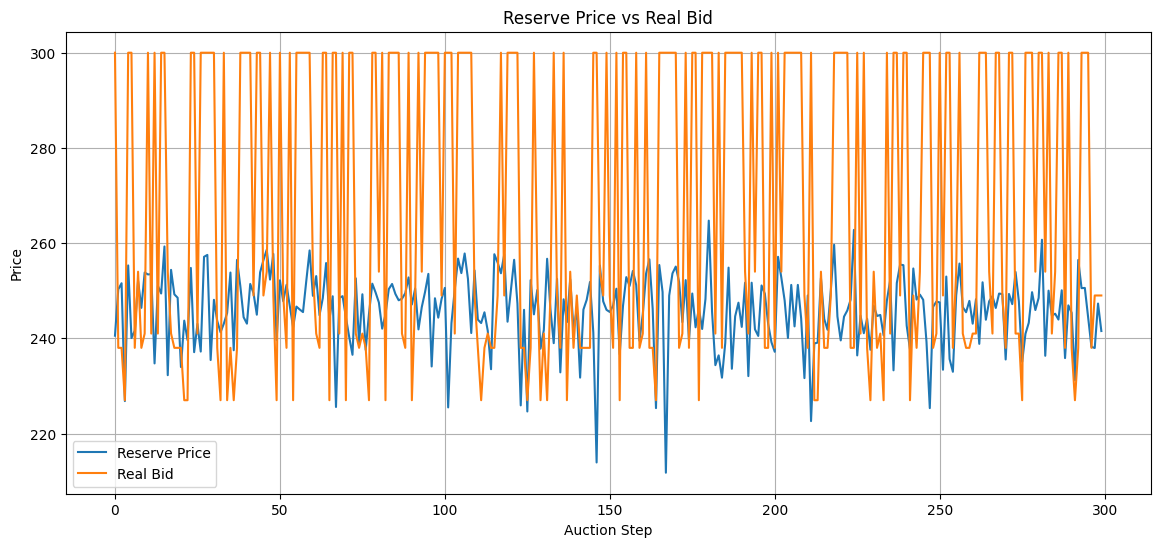

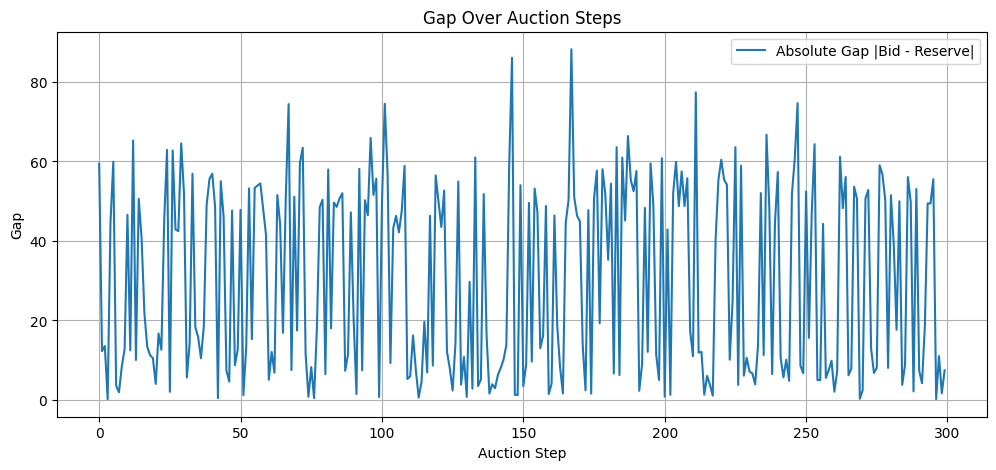

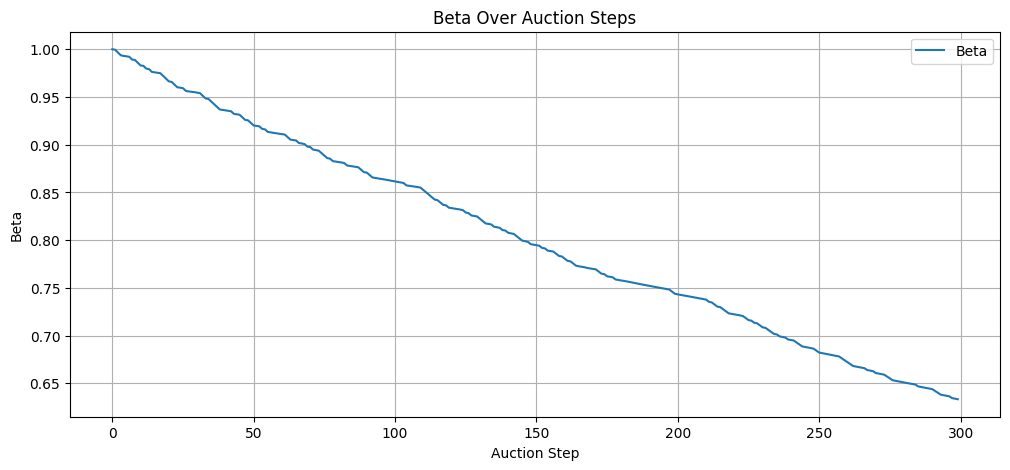

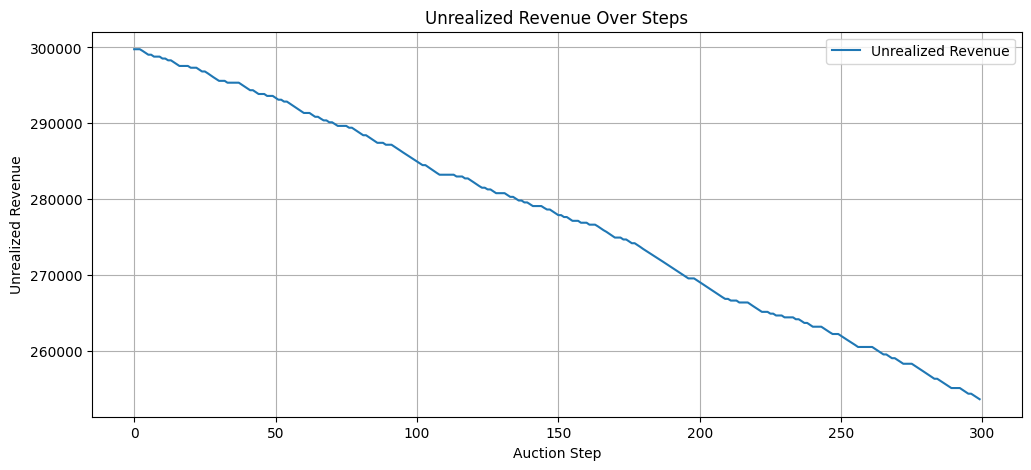

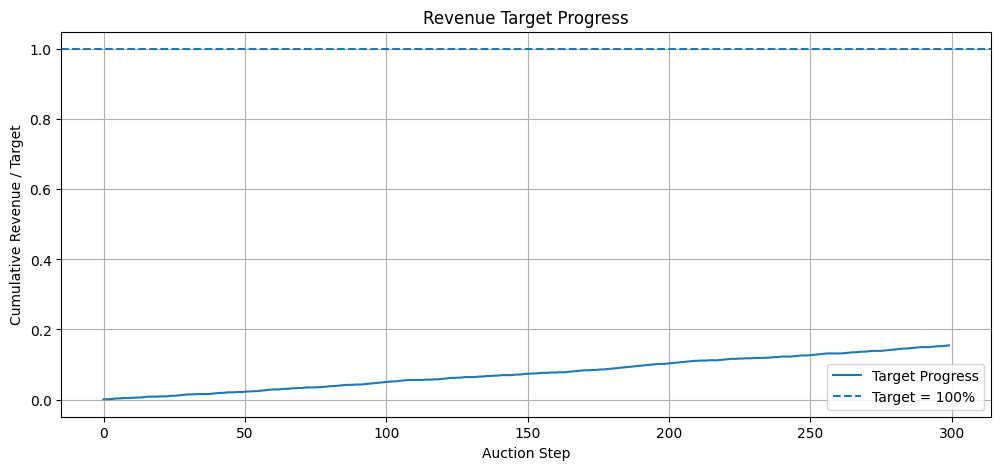

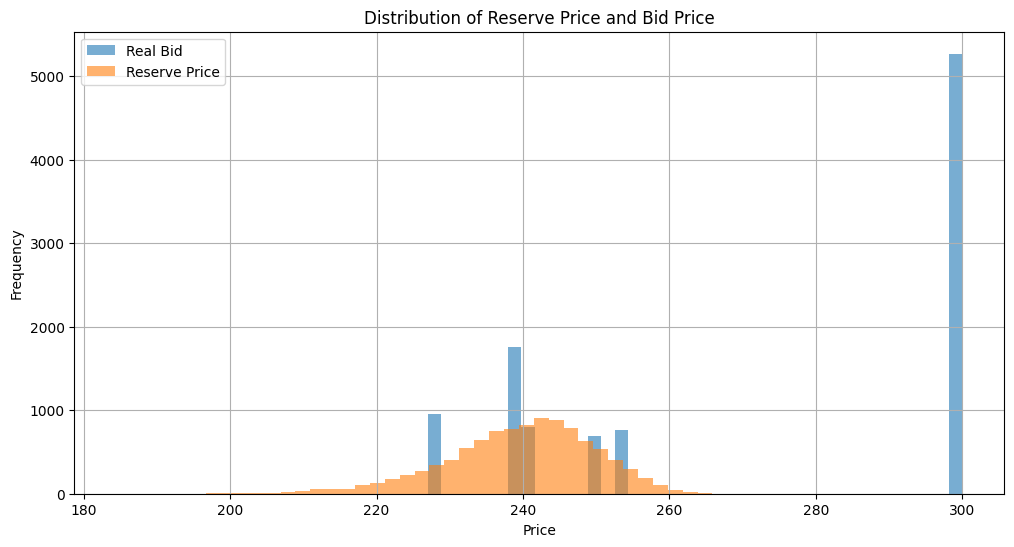

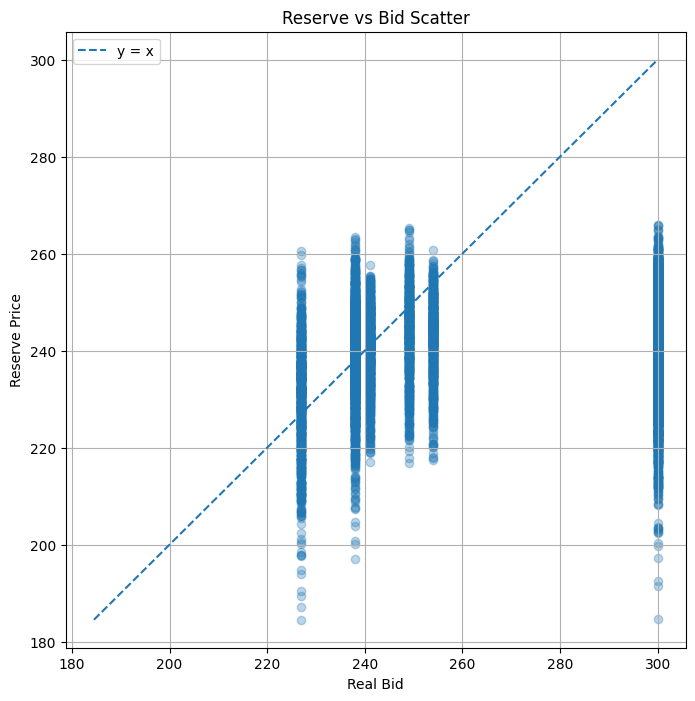

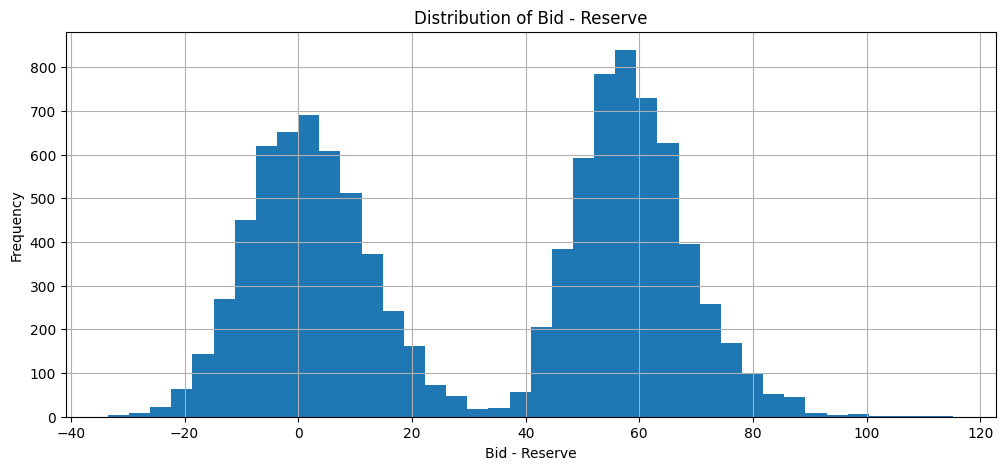

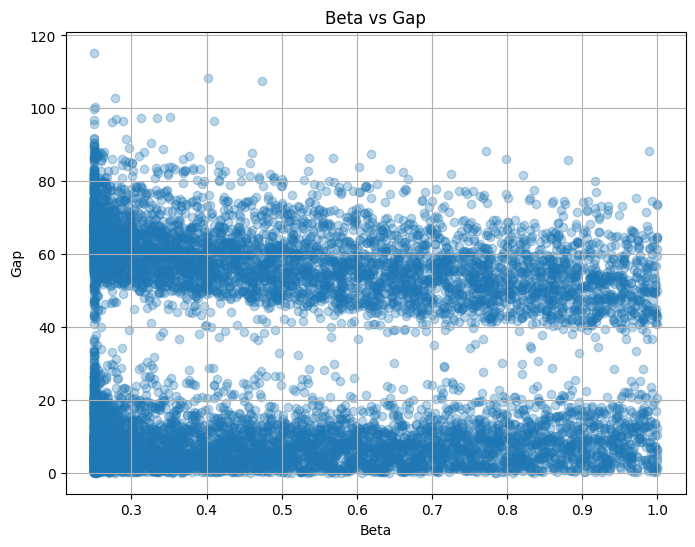


===== SUMMARY STATS =====
            reserve           bid           gap    signed_gap          beta  \
count  10240.000000  10240.000000  10240.000000  10240.000000  10240.000000   
mean     239.670764    271.037695     34.633550     31.366931      0.510503   
std       10.148747     30.409096     26.728036     30.496022      0.231434   
min      184.499921    227.000000      0.002459    -33.479075      0.250000   
25%      233.738229    238.000000      7.408250      1.800884      0.287675   
50%      240.665722    300.000000     42.660296     42.660296      0.460129   
75%      246.660172    300.000000     58.816557     58.816557      0.699319   
max      265.892893    300.000000    115.267876    115.267876      1.000000   

             reward       revenue  unrealized_revenue  target_progress  
count  10240.000000  10240.000000        10240.000000     10240.000000  
mean       0.033118    186.281693       209657.734807         0.301141  
std        0.051341     98.980326        5

In [5]:
best_model = PPO.load(log_dir + "best_model/best_model", env=test_env)

df_eval = evaluate_agent_detail_with_plots(
    best_model,
    test_env,
    num_episodes=10,
    sample_n=300
)

In [6]:
# tensorboard --logdir=./logs_ppo_rtb/